# AdaBoost: Weak Learners, Strong Decisions

Boosting addresses a central challenge in machine learning: how to build a strong classifier from simple components. Each weak learner captures only a crude geometric cue, but a weighted combination can recover highly non-linear decision boundaries.

The key stakes are both theoretical and practical:
- A greedy, stage-wise optimization of an exponential objective.
- A dynamic reweighting of data points that focuses learning on hard examples.
- A transparent link between optimization, margins, and classification performance.

We work in binary classification with labels $y_i\in\{-1,+1\}$ and model
$$
F_T(x)=\sum_{t=1}^T \alpha_t h_{j_t}(x),\qquad \hat y(x)=\operatorname{sign}(F_T(x)).
$$
At iteration $t$, AdaBoost selects the weak learner minimizing weighted error under $D_t$ and updates
$$
\alpha_t=\frac12\log\frac{1-\varepsilon_t}{\varepsilon_t},\qquad
D_{t+1}(i)\propto D_t(i)\exp\big(-\alpha_t y_i h_{j_t}(x_i)\big).
$$

## Environment and notation

This cell sets plotting style and imports. We will represent the sample as a matrix $X\in\mathbb{R}^{n\times 2}$ and labels as $y\in\{-1,+1\}^n$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from ipywidgets import interact, IntSlider

plt.rcParams['figure.dpi'] = 120
rng = np.random.default_rng(2)

## Synthetic dataset

We build a two-class planar distribution with partial overlap. This provides a clear setting where single linear separators are weak, but a boosted ensemble can succeed.

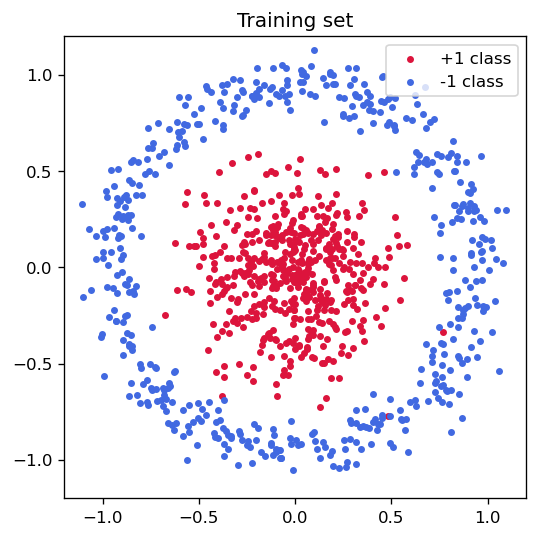

In [2]:
n = 1000
n_half = n // 2

theta = 2 * np.pi * rng.random(n_half)
R = 0.95
r = R * (1 + 0.08 * rng.standard_normal(n_half))
x_ring = np.c_[np.cos(theta) * r, np.sin(theta) * r]
x_blob = 0.25 * rng.standard_normal((n_half, 2))

X = np.vstack([x_blob, x_ring])
y = np.r_[np.ones(n_half), -np.ones(n_half)]

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X[y > 0, 0], X[y > 0, 1], s=10, c='crimson', label='+1 class')
ax.scatter(X[y < 0, 0], X[y < 0, 1], s=10, c='royalblue', label='-1 class')
ax.set_title('Training set')
ax.set_aspect('equal')
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.legend(loc='upper right')
plt.show()

## Weak learner family

We sample many oriented threshold classifiers
$$
h_j(x)=\operatorname{sign}(\langle u_j,x\rangle-t_j),
$$
then flip their orientation when needed so each has correlation with labels.

In [3]:
r = 120
angles = 2 * np.pi * rng.random(r)
u = np.vstack([np.cos(angles), np.sin(angles)])
t = 1.2 * (2 * rng.random(r) - 1)

raw = X @ u - t
acc = (np.sign(raw) == y[:, None]).mean(axis=0)
sigma = np.sign(acc - 0.5 + 1e-10)
H = np.sign(raw * sigma[None, :])
H[H == 0] = 1
E = (H != y[:, None]).astype(float)

print('Weak learner error range:', E.mean(axis=0).min(), E.mean(axis=0).max())

Weak learner error range: 0.33 0.5


## Local decision geometries

Before boosting, it is helpful to inspect individual weak learners and their induced partition of the plane.

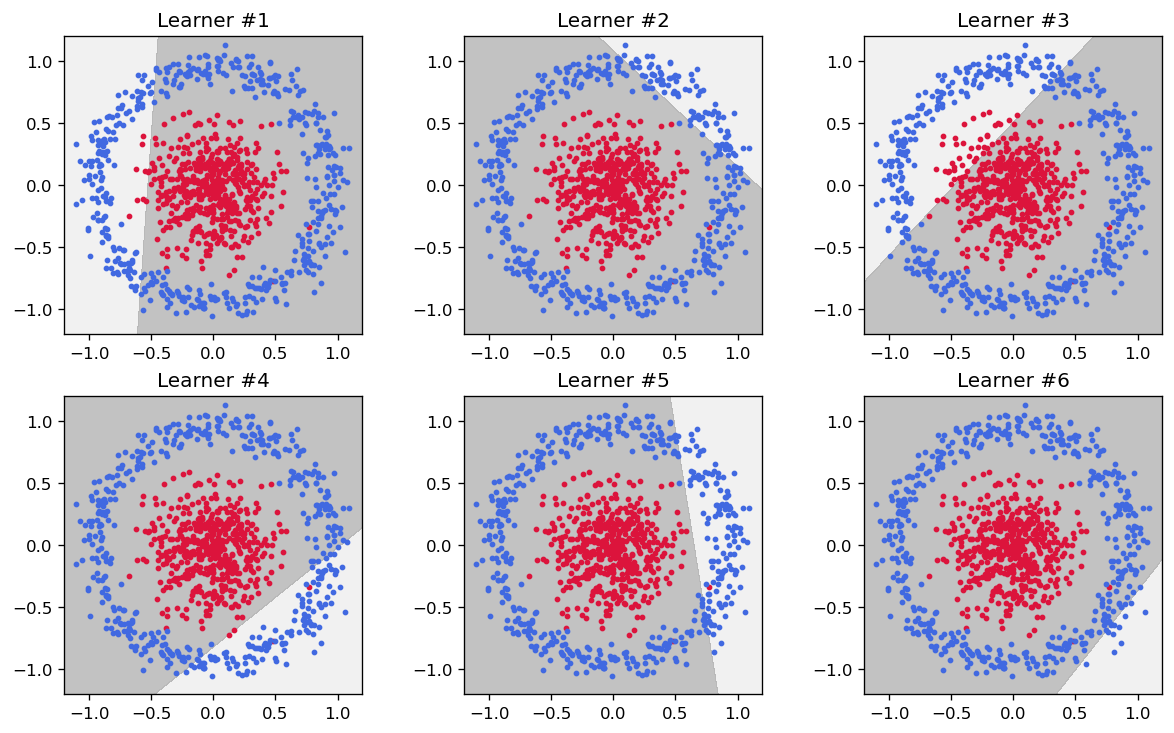

In [4]:
s = np.linspace(-1.2, 1.2, 300)
U, V = np.meshgrid(s, s)
Z = np.c_[U.ravel(), V.ravel()]

fig, axes = plt.subplots(2, 3, figsize=(10, 6), constrained_layout=True)
for k, ax in enumerate(axes.flat):
    pred = np.sign((Z @ u[:, k] - t[k]) * sigma[k]).reshape(U.shape)
    pred[pred == 0] = 1
    ax.contourf(U, V, pred, levels=[-1, 0, 1], cmap='Greys', alpha=0.35)
    ax.scatter(X[y > 0, 0], X[y > 0, 1], s=6, c='crimson')
    ax.scatter(X[y < 0, 0], X[y < 0, 1], s=6, c='royalblue')
    ax.set_aspect('equal')
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_title(f'Learner #{k+1}')
plt.show()

## Boosting dynamics

This implementation follows the exact AdaBoost update with the exponential surrogate
$$
\mathcal L_{\exp}(w)=\frac1n\sum_{i=1}^n e^{-y_i(Hw)_i}.
$$
At each round we pick the best coordinate (weak learner) under the current distribution $D_t$.

In [5]:
def run_adaboost(H, E, y, n_iter=500):
    n, r = H.shape
    w = np.zeros(r)
    D = np.ones(n) / n
    exp_losses = []
    learner_ids = []
    alphas = []
    D_hist = [D.copy()]

    for _ in range(n_iter):
        F = H @ w
        exp_losses.append(np.mean(np.exp(-y * F)))
        weighted_errors = (D[:, None] * E).sum(axis=0)
        j = np.argmin(weighted_errors)
        eps = np.clip(weighted_errors[j], 1e-8, 1 - 1e-8)
        a = 0.5 * np.log((1 - eps) / eps)
        w[j] += a
        D *= np.exp(-a * y * H[:, j])
        D /= D.sum()
        learner_ids.append(int(j))
        alphas.append(float(a))
        D_hist.append(D.copy())

    return {
        'w': w,
        'exp_losses': np.array(exp_losses),
        'learner_ids': np.array(learner_ids),
        'alphas': np.array(alphas),
        'D_hist': D_hist,
    }

boost = run_adaboost(H, E, y, n_iter=500)

## Optimization and sample-weight concentration

We inspect the loss trajectory and compare $D_1$ to $D_T$: harder points should accumulate larger weights.

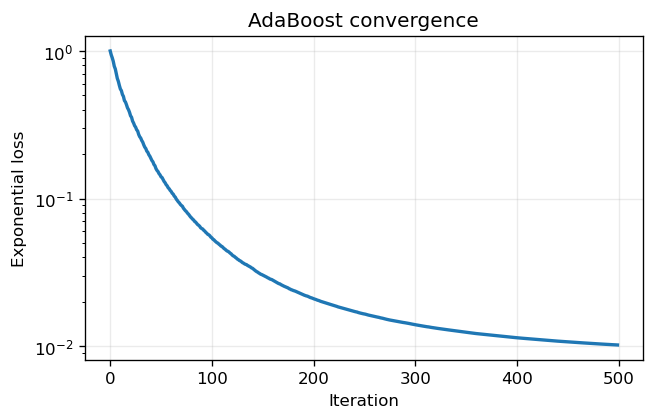

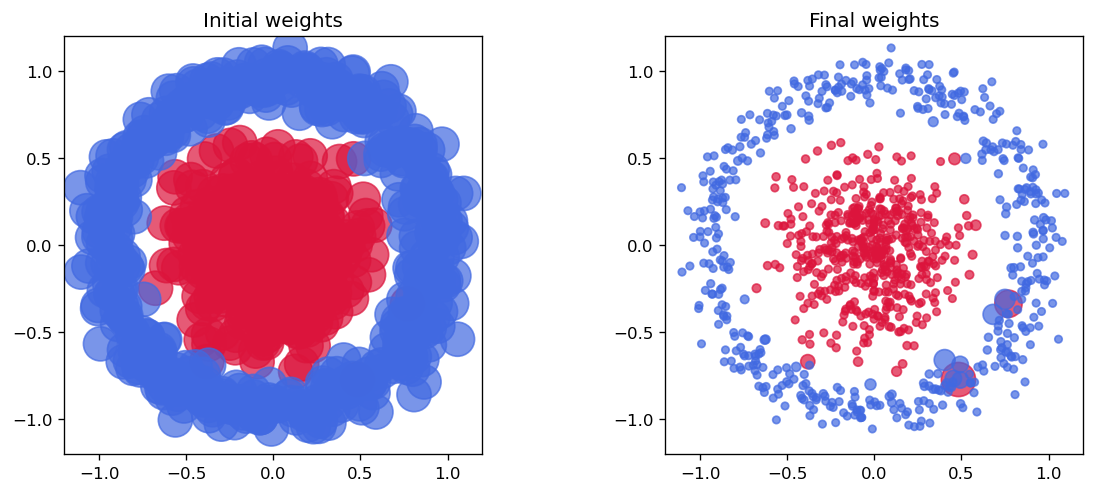

In [6]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(boost['exp_losses'], lw=2)
ax.set_yscale('log')
ax.set_xlabel('Iteration')
ax.set_ylabel('Exponential loss')
ax.set_title('AdaBoost convergence')
ax.grid(alpha=0.25)
plt.show()

D0 = boost['D_hist'][0]
Dend = boost['D_hist'][-1]
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
for ax, Dcur, title in zip(axes, [D0, Dend], ['Initial weights', 'Final weights']):
    sizes = 20 + 400 * (Dcur / Dcur.max())
    ax.scatter(X[y > 0, 0], X[y > 0, 1], s=sizes[y > 0], c='crimson', alpha=0.7)
    ax.scatter(X[y < 0, 0], X[y < 0, 1], s=sizes[y < 0], c='royalblue', alpha=0.7)
    ax.set_aspect('equal')
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_title(title)
plt.show()

## Interactive ensemble boundary

This widget displays the score field $F_t(x)$ during training. The zero-level set approximates the final classifier boundary.

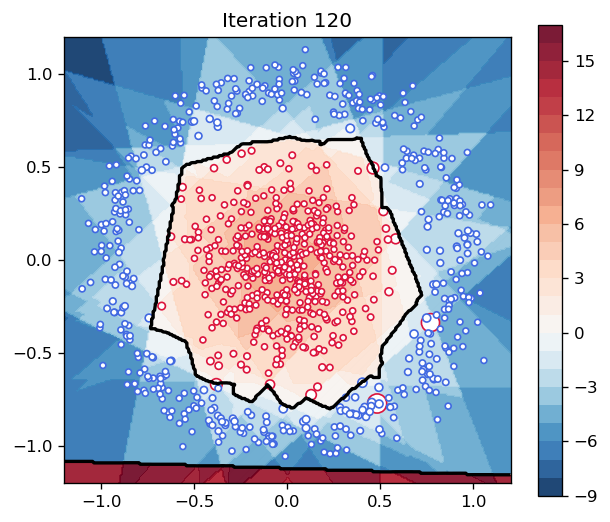

In [7]:
grid_scores = []
# Precompute weak-learner predictions on the grid once (large speedup in headless execution).
g = np.sign((Z @ u - t) * sigma).astype(float)
g[g == 0] = 1
W = np.zeros_like(boost['w'])
for j, a in zip(boost['learner_ids'], boost['alphas']):
    W[j] += a
    grid_scores.append((g @ W).reshape(U.shape))

def show_round(it=1):
    score = grid_scores[it - 1]
    D = boost['D_hist'][it]
    fig, ax = plt.subplots(figsize=(6, 6))
    norm = TwoSlopeNorm(vmin=score.min(), vcenter=0.0, vmax=score.max())
    im = ax.contourf(U, V, score, levels=25, cmap='RdBu_r', norm=norm, alpha=0.9)
    ax.contour(U, V, score, levels=[0], colors='k', linewidths=2)
    sizes = 12 + 120 * (D / D.max())
    ax.scatter(X[y > 0, 0], X[y > 0, 1], s=sizes[y > 0], c='white', edgecolor='crimson', linewidth=1)
    ax.scatter(X[y < 0, 0], X[y < 0, 1], s=sizes[y < 0], c='white', edgecolor='royalblue', linewidth=1)
    ax.set_aspect('equal')
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_title(f'Iteration {it}')
    fig.colorbar(im, ax=ax, shrink=0.85)
    plt.show()

# Static call for headless execution (keeps a representative rendered decision map).
show_round(it=min(120, len(grid_scores)));

## Bibliographical resources

- Yoav Freund and Robert E. Schapire, *A Decision-Theoretic Generalization of On-Line Learning and an Application to Boosting*, 1997.
- Robert E. Schapire and Yoram Singer, *Improved Boosting Algorithms Using Confidence-rated Predictions*, 1999.
- Trevor Hastie, Robert Tibshirani, Jerome Friedman, *The Elements of Statistical Learning*, chapters on boosting.